In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from traffic_monitoring_ml.config import COLLISION_VALUE_MAP_PATH, CASUALTY_VALUE_MAP_PATH, VEHICLE_VALUE_MAP_PATH, X_TRAIN_PATH, Y_TRAIN_PATH, GROUPS_TRAIN_PATH, SELECTED_FEATURES_PATH
from traffic_monitoring_ml.utils import load_pickle, save_json, get_day_period_from_time
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import GroupShuffleSplit

In [2]:
pd.set_option('display.max_columns', 100)

In [3]:
casualty_value_map = load_pickle(Path(CASUALTY_VALUE_MAP_PATH))
vehicle_value_map = load_pickle(Path(VEHICLE_VALUE_MAP_PATH))
collision_value_map = load_pickle(Path(COLLISION_VALUE_MAP_PATH))

## Carga y decodificación

Cargamos los datos de entrenamiento preprocesados y aplicamos los `value_map` guardados
en el paso anterior para que las variables categóricas sean legibles. Esto también es
necesario para que CatBoost las reconozca correctamente como categorías y sacar el máximo partido al modelo.

In [4]:
X_train = (pd.read_parquet(Path(X_TRAIN_PATH))
           .replace(casualty_value_map)
           .replace(collision_value_map)
           .replace(vehicle_value_map))
y_train = pd.read_parquet(Path(Y_TRAIN_PATH)).squeeze()

In [5]:
X_train.head()

,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_imd_decile,casualty_injury_based,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane,junction_location,skidding_and_overturning,hit_object_in_carriageway,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,vehicle_left_hand_drive,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,driver_imd_decile,escooter_flag,longitude,latitude,police_force,number_of_vehicles,number_of_casualties,date,day_of_week,time,first_road_class,road_type,speed_limit,junction_detail,second_road_class,pedestrian_crossing,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,trunk_road_flag,collision_injury_based,day_period,geo_hash
0,Pedestrian,Female,24,21 - 25,"In centre of carriageway - not on refuge, isla...",Unknown or other,Not car passenger,Not a bus or coach passenger,No / Not applicable,Pedestrian,More deprived 20-30%,Based on severity reporting,Car,No tow/articulation,unknown (self reported),unknown (self reported),unknown (self reported),unknown (self reported),Not at or within 20 metres of junction,unknown (self reported),unknown (self reported),unknown (self reported),unknown (self reported),unknown (self reported),Unknown,Not known or not requested,Not known,Data missing or out of range,Data missing or out of range,Data missing or out of range,Vehicle was not an e-scooter,0.057177,51.524751,Metropolitan Police,2,1,14/11/2020,Saturday,19:23,A,Single carriageway,30,Not at junction or within 20 metres,Not at junction or within 20 metres,unknown (self reported),Darkness - lighting unknown,Raining no high winds,Wet or damp,unknown (self reported),No hazards,Urban,Non-trunk,Based on severity reporting,evening,u10j
1,Pedestrian,Female,95,Over 75,"In carriageway, crossing elsewhere",Crossing from driver's nearside,Not car passenger,Not a bus or coach passenger,No / Not applicable,Pedestrian,Less deprived 40-50%,Based on severity reporting,Car,No tow/articulation,Turning right,East,North,On main carriageway (not in restricted lane),Entering main road,No skidding,No hit,Did not leave carriageway,No hit,Front,No,Not known or not requested,Male,28,26 - 35,Most deprived 10%,Vehicle was not an e-scooter,-1.089183,52.963425,Nottinghamshire,1,1,12/07/2020,Sunday,14:37,Unclassified,Single carriageway,30,T or staggered junction,Unclassified,No physical crossing facility within 50m,Daylight,Fine no high winds,Dry,No,No hazards,Urban,Non-trunk,Based on severity reporting,afternoon,gcrj
2,Pedestrian,Male,39,36 - 45,"In carriageway, crossing elsewhere",Crossing from driver's nearside,Not car passenger,Not a bus or coach passenger,No / Not applicable,Pedestrian,More deprived 10-20%,Based on Injury code reporting,Car,No tow/articulation,Going ahead,West,North,On main carriageway (not in restricted lane),Mid Junction - on roundabout or on main road,No skidding,No hit,Did not leave carriageway,No hit,Front,No,Not known or not requested,Not known,Data missing or out of range,Data missing or out of range,Data missing or out of range,Vehicle was not an e-scooter,-0.474256,52.135547,Bedfordshire,1,1,26/11/2020,Thursday,21:00,Unclassified,Single carriageway,30,Crossroads,Unclassified,No physical crossing facility within 50m,Darkness - lights unlit,Fog or mist,Wet or damp,No,No hazards,Urban,Non-trunk,Based on Injury code reporting,night,gcr8
3,Pedestrian,Male,63,56 - 65,On footway or verge,Unknown or other,Not car passenger,Not a bus or coach passenger,Not Known,Pedestrian,More deprived 20-30%,Based on Injury code reporting,Car,No tow/articulation,Going ahead,South West,North East,On main carriageway (not in restricted lane),Not at or within 20 metres of junction,No skiddin

### Features invalidas

In [6]:
X_train.columns

Index(['casualty_class', 'sex_of_casualty', 'age_of_casualty',
       'age_band_of_casualty', 'pedestrian_location', 'pedestrian_movement',
       'car_passenger', 'bus_or_coach_passenger',
       'pedestrian_road_maintenance_worker', 'casualty_type',
       'casualty_imd_decile', 'casualty_injury_based', 'vehicle_type',
       'towing_and_articulation', 'vehicle_manoeuvre',
       'vehicle_direction_from', 'vehicle_direction_to',
       'vehicle_location_restricted_lane', 'junction_location',
       'skidding_and_overturning', 'hit_object_in_carriageway',
       'vehicle_leaving_carriageway', 'hit_object_off_carriageway',
       'first_point_of_impact', 'vehicle_left_hand_drive',
       'journey_purpose_of_driver', 'sex_of_driver', 'age_of_driver',
       'age_band_of_driver', 'driver_imd_decile', 'escooter_flag', 'longitude',
       'latitude', 'police_force', 'number_of_vehicles',
       'number_of_casualties', 'date', 'day_of_week', 'time',
       'first_road_class', 'road_type', '

## Eliminación de features no disponibles en inferencia

Descartamos features que, aunque están en el dataset de entrenamiento y tienen buena capacidad predictiva, no estarían
disponibles en el momento de predecir (datos administrativos post-accidente, índices de deprivación del conductor/víctima, etc.).
Incluirlas introduciría data leakage y haría el modelo no desplegable.

In [7]:
#No se pueden obtener en inferencia
X_train = X_train.drop(columns=[
    'pedestrian_road_maintenance_worker',
    'casualty_injury_based',
    'towing_and_articulation',
    'vehicle_direction_from',
    'vehicle_direction_to',
    'vehicle_location_restricted_lane',
    'journey_purpose_of_driver',
    'police_force',
    'collision_injury_based',
    'casualty_imd_decile',
    'driver_imd_decile',
])

In [8]:
X_train.columns

Index(['casualty_class', 'sex_of_casualty', 'age_of_casualty',
       'age_band_of_casualty', 'pedestrian_location', 'pedestrian_movement',
       'car_passenger', 'bus_or_coach_passenger', 'casualty_type',
       'vehicle_type', 'vehicle_manoeuvre', 'junction_location',
       'skidding_and_overturning', 'hit_object_in_carriageway',
       'vehicle_leaving_carriageway', 'hit_object_off_carriageway',
       'first_point_of_impact', 'vehicle_left_hand_drive', 'sex_of_driver',
       'age_of_driver', 'age_band_of_driver', 'escooter_flag', 'longitude',
       'latitude', 'number_of_vehicles', 'number_of_casualties', 'date',
       'day_of_week', 'time', 'first_road_class', 'road_type', 'speed_limit',
       'junction_detail', 'second_road_class', 'pedestrian_crossing',
       'light_conditions', 'weather_conditions', 'road_surface_conditions',
       'special_conditions_at_site', 'carriageway_hazards',
       'urban_or_rural_area', 'trunk_road_flag', 'day_period', 'geo_hash'],
      dtype

## Agrupación de edades

Eliminamos las edades exactas (`age_of_casualty`, `age_of_driver`) y conservamos
únicamente sus versiones agrupadas por bandas. Esto reduce ruido y evita que el modelo
sobre ajuste a edades muy específicas con poca representación. Catboost las manejara como features categóricas

In [9]:
#Nos quedamos con las agrupaciones de categorías de las edades
X_train = X_train.drop(columns=[
    'age_of_casualty',
    'age_of_driver',
])

## Selección de features con CatBoost

Entrenamos un modelo CatBoost preliminar con early stopping sobre un split de
validación interno. Usamos dos métricas de importancia complementarias:

- **Model Importance (feature importance intrínseca)**: mide cuánto contribuye cada
  feature a las divisiones del árbol durante el entrenamiento.
- **Permutation Importance (LossFunctionChange)**: mide cuánto empeora el AUC al
  permutar aleatoriamente cada variable en el conjunto de validación. Es más robusta
  frente a correlaciones entre features.

La comparación de ambas importancias nos ayuda a identificar variables redundantes
o correlacionadas que el propio modelo puede sobrevalorar.

In [10]:
#Variables que voy eliminando a mano tras evaluar cada iteración de importancias
X_train = X_train.drop(columns=[
    'date',
    'time',
    'longitude',
    'latitude',
    'day_of_week',
    'casualty_class',
    'escooter_flag',
    'bus_or_coach_passenger',
    'car_passenger',
    'carriageway_hazards',
    'pedestrian_crossing',
    'junction_detail',
    'sex_of_driver',
    'road_surface_conditions',
    'second_road_class',
    'weather_conditions',
    'trunk_road_flag',
    'first_road_class',
    'sex_of_casualty'
])

In [11]:
X_train.columns # Variables seleccionadas

Index(['age_band_of_casualty', 'pedestrian_location', 'pedestrian_movement',
       'casualty_type', 'vehicle_type', 'vehicle_manoeuvre',
       'junction_location', 'skidding_and_overturning',
       'hit_object_in_carriageway', 'vehicle_leaving_carriageway',
       'hit_object_off_carriageway', 'first_point_of_impact',
       'vehicle_left_hand_drive', 'age_band_of_driver', 'number_of_vehicles',
       'number_of_casualties', 'road_type', 'speed_limit', 'light_conditions',
       'special_conditions_at_site', 'urban_or_rural_area', 'day_period',
       'geo_hash'],
      dtype='str')

## Split de validación por grupos de accidente

Para evaluar el modelo de selección de features necesitamos un conjunto de validación
separado del entrenamiento. Usamos `GroupShuffleSplit` respetando los grupos por
`collision_index`, de modo que todas las víctimas de un mismo accidente queden en el
mismo fold. Este split se usa como `eval_set` para el early stopping de CatBoost y
para calcular la permutation importance sobre datos no vistos durante el entrenamiento. Esta técnica es necesaria para no filtrar datos y que las metricas se vean infladas debido a ello

In [12]:
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
groups_train = pd.read_parquet(Path(GROUPS_TRAIN_PATH)).squeeze()

train_idx, val_idx = next(gss_val.split(X_train, y_train, groups_train))

X_tr = X_train.iloc[train_idx]
X_val = X_train.iloc[val_idx]
y_tr = y_train.iloc[train_idx]
y_val = y_train.iloc[val_idx]

cat_features = [col for col in X_train.columns if X_train[col].dtype in ['object', 'str']]

#para early stoping de catboost
eval_set = Pool(X_val, y_val, cat_features=cat_features)

ftr_model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.1,
    depth=8,
    verbose=100,
    eval_metric='AUC',
    task_type='GPU',
    devices='0',
    early_stopping_rounds=20,
    auto_class_weights='Balanced',
)

ftr_model.fit(X_tr, y_tr, cat_features=cat_features, eval_set=eval_set)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7264856	best: 0.7264856 (0)	total: 576ms	remaining: 14m 23s
100:	test: 0.7595012	best: 0.7595012 (100)	total: 57.2s	remaining: 13m 12s
200:	test: 0.7610734	best: 0.7610734 (200)	total: 1m 54s	remaining: 12m 18s
bestTest = 0.7615315318
bestIteration = 271
Shrink model to first 272 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=8, devices='0', early_stopping_rounds=20, eval_metric='AUC', iterations=1500, learning_rate=0.1, task_type='GPU', verbose=100)

In [13]:
model_importance = ftr_model.get_feature_importance()
permutation_importance = ftr_model.get_feature_importance(
    data=eval_set,
    type='LossFunctionChange'  #permutation importance en catboost
)

feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'model_importance': model_importance,
    'permutation_importance': permutation_importance,

}).sort_values(by='permutation_importance',ascending=False)

In [14]:
feat_imp #resultado consistente, dominancia de tipo de victima

,feature,model_importance,permutation_importance
3,casualty_type,12.908093,0.006170
22,geo_hash,10.196967,0.003325
11,first_point_of_impact,8.780277,0.002782
17,speed_limit,6.186010,0.002086
0,age_band_of_casualty,6.633026,0.001598
9,vehicle_leaving_carriageway,4.324090,0.001461
14,number_of_vehicles,6.299125,0.001262
5,vehicle_manoeuvre,6.465749,0.001261
13,age_band_of_driver,3.912598,0.001062
7,skidding_and_overturning,2.584889,0.000584


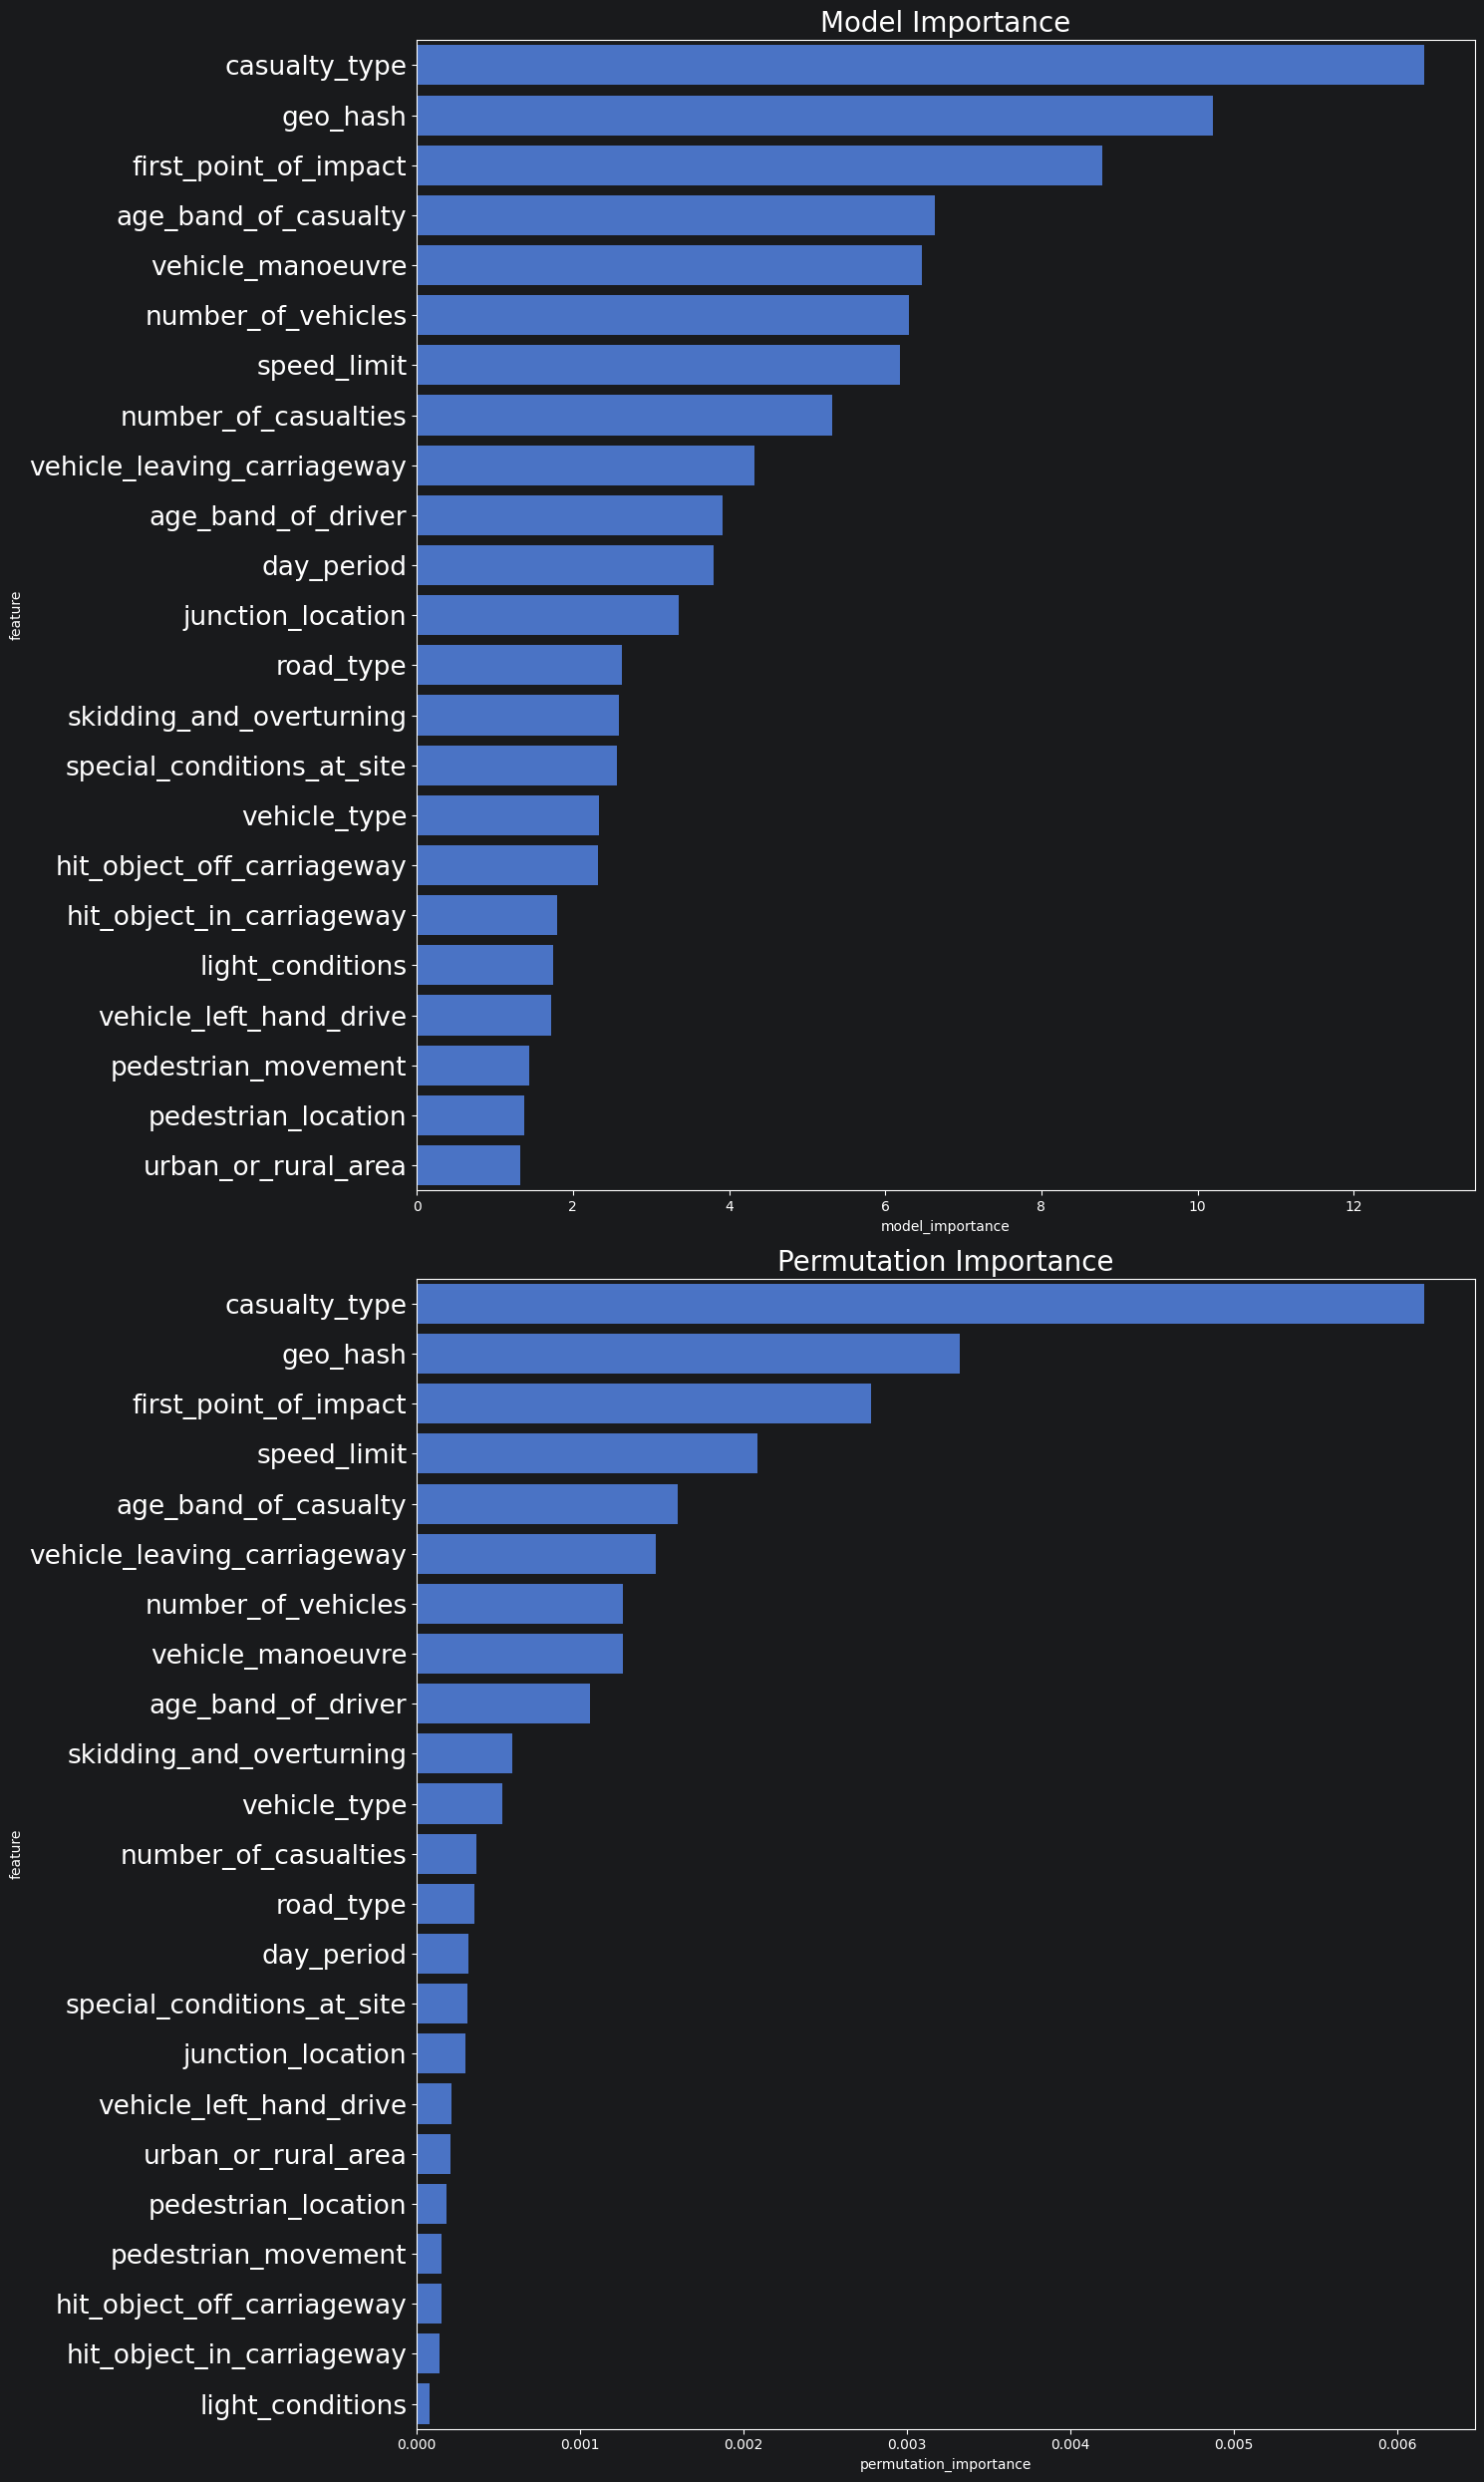

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(15, 25))

sns.barplot(data=feat_imp.sort_values(by='model_importance', ascending=False),x='model_importance',y='feature',ax=ax1)
ax1.tick_params(axis='y', labelsize=19)
ax1.set_title("Model Importance", size=20)

sns.barplot(data=feat_imp,x='permutation_importance',y='feature',ax=ax2
)
ax2.tick_params(axis='y', labelsize=19)
ax2.set_title('Permutation Importance', size=20)


plt.tight_layout()
plt.show()

## Guardado de features seleccionadas

Guardamos la lista final de features seleccionadas en un archivo JSON. Esto garantiza
reproducibilidad el notebook y en producción.

In [16]:
save_json(Path(SELECTED_FEATURES_PATH), X_train.columns.tolist())